In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF
#%pip install nbconvert
from pathlib import Path
import nbformat
from nbconvert import HTMLExporter

# Export this notebook to HTML (it uses the last SAVED version of the .ipynb file)
notebook_file = Path("02_walmart_eda.ipynb")

with notebook_file.open("r", encoding="utf-8") as f:
    notebook = nbformat.read(f, as_version=4)

exporter = HTMLExporter()
exporter.exclude_input = False  # False keeps the code in the HTML (True would hide it)

html, resources = exporter.from_notebook_node(notebook)

destination = notebook_file.with_suffix(".html")
destination.write_text(html, encoding="utf-8")

print(f"HTML created: {destination}")

HTML created: 02_walmart_eda.html


## Walmart EDA

In [2]:

wmt = pd.read_csv('data/walmart_history.csv', index_col=0, parse_dates=True)
# The dates in this file include a time-zone offset (-05:00 in winter, -04:00 in summer).
# Because the offset changes, recent pandas versions keep them as text, so we keep only
# the day ('YYYY-MM-DD', the first 10 characters) and turn it into real dates for the charts.
wmt.index = pd.to_datetime(wmt.index.astype(str).str[:10])
daily_returns = pd.read_csv('data/daily_log_returns.csv', index_col=0, parse_dates=True)['WMT'].dropna()
weekly_returns = pd.read_csv('data/weekly_log_returns.csv', index_col=0, parse_dates=True)['WMT'].dropna()
monthly_returns = pd.read_csv('data/monthly_log_returns.csv', index_col=0, parse_dates=True)['WMT'].dropna()
prices = pd.read_csv('data/clean_prices.csv', index_col=0, parse_dates=True)

display(daily_returns.head())


Date
2010-01-05   -0.010007
2010-01-06   -0.002238
2010-01-07    0.000560
2010-01-08   -0.005050
2010-01-11    0.016367
Name: WMT, dtype: float64

## Technical indicators: smoothing the price path

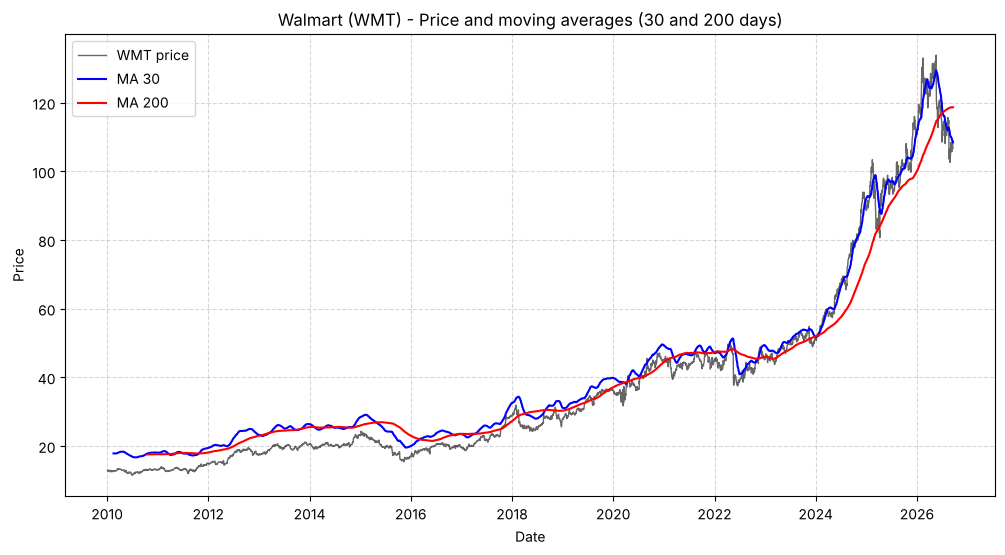

In [3]:
# Compute the simple moving averages (SMA) based on 'Adj Close'
# (the same adjusted price that is plotted below; using 'Close' would put the averages
#  above the adjusted price line in the early years, because 'Close' ignores dividends)
wmt['MA_30'] = wmt['Adj Close'].rolling(window=30).mean()
wmt['MA_200'] = wmt['Adj Close'].rolling(window=200).mean()


plt.figure(figsize=(12, 6))

# Adjusted price line
plt.plot(wmt.index, wmt['Adj Close'], label='WMT price', color='black', alpha=0.6, linewidth=1)

# Moving averages
plt.plot(wmt.index, wmt['MA_30'], label='MA 30 ', color='blue', linewidth=1.5)
plt.plot(wmt.index, wmt['MA_200'], label='MA 200 ', color='red', linewidth=1.5)

# Chart settings
plt.title('Walmart (WMT) - Price and moving averages (30 and 200 days)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Save the chart in the figures folder
plt.savefig('../figures/wmt_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

##  Walmart log returns

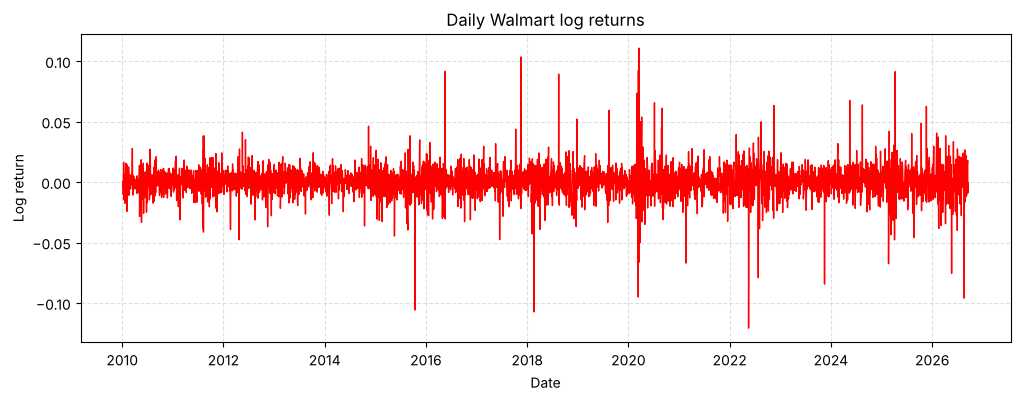

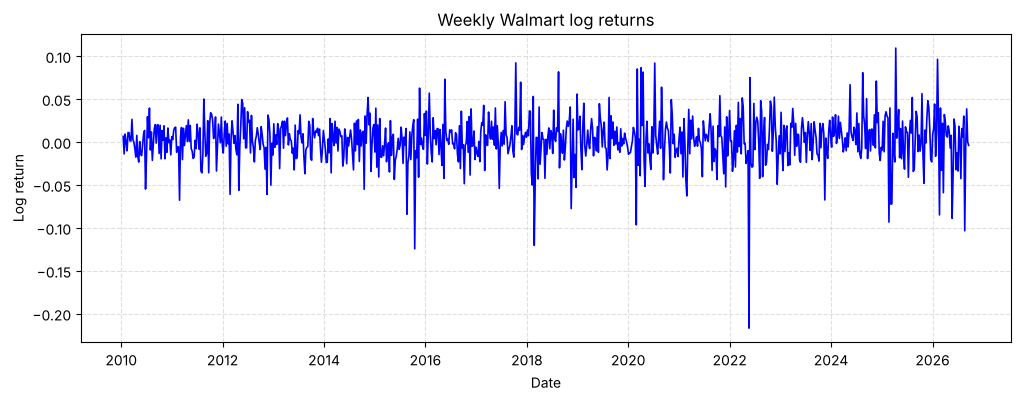

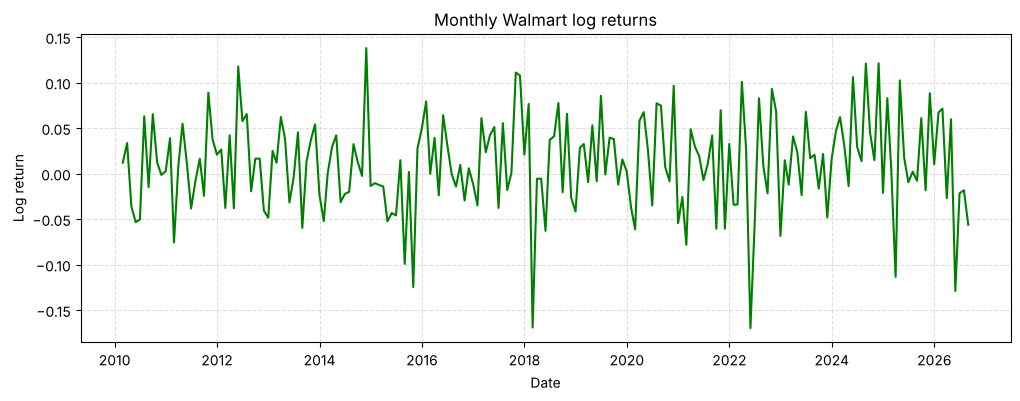

In [4]:


# --- Daily
plt.figure(figsize=(12, 4))
plt.plot(daily_returns.index, daily_returns, color='red', linewidth=1)
plt.title('Daily Walmart log returns')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('../figures/day_log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Weekly ---
plt.figure(figsize=(12, 4))
plt.plot(weekly_returns.index, weekly_returns, color='blue', linewidth=1.2)
plt.title('Weekly Walmart log returns')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('../figures/week_log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Monthly ---
plt.figure(figsize=(12, 4))
plt.plot(monthly_returns.index, monthly_returns, color='green', linewidth=1.5)
plt.title('Monthly Walmart log returns')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('../figures/month_log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Normalised price

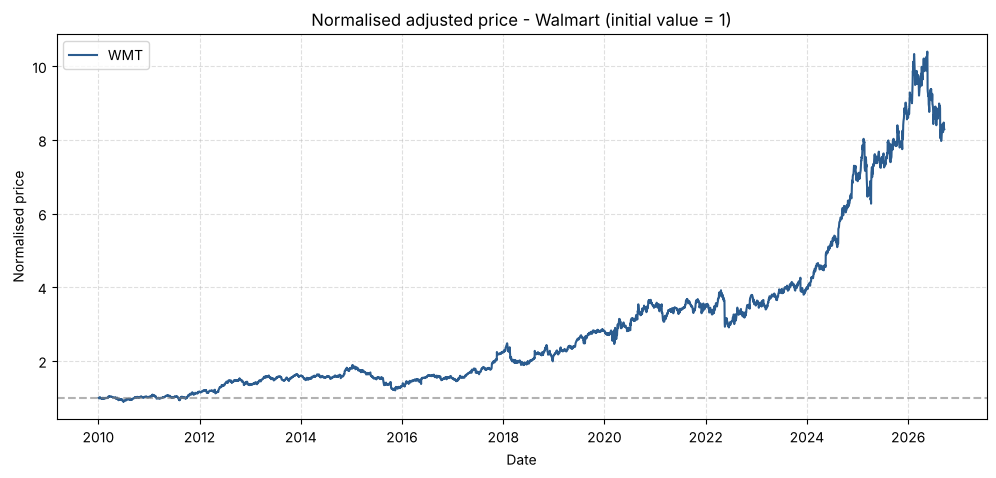

In [5]:
wmt_price = prices['WMT']

# Normalise the price by dividing it by the value on the first day
wmt_normalised = wmt_price / wmt_price.iloc[0]


plt.figure(figsize=(12, 5))
plt.plot(wmt_normalised.index, wmt_normalised, color='#2B5C8F', linewidth=1.5, label='WMT')

# Settings
plt.title('Normalised adjusted price - Walmart (initial value = 1)')
plt.xlabel('Date')
plt.ylabel('Normalised price')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6)  # Reference line
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig('../figures/normalized_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Annualised realised performance

In [6]:
#Select Walmart's adjusted price and compute the daily simple returns
simple_returns = wmt_price.pct_change().dropna()

# Annualisation parameters
scale = 252  # Trading days in a year
rf = 0.0     # (zero risk-free rate)

# Annualised metrics
# Annualised compound return (CAGR)
annualised_return = (1 + simple_returns).prod() ** (scale / len(simple_returns)) - 1

# Annualised standard deviation (volatility)
annualised_volatility = simple_returns.std() * np.sqrt(scale)

# Annualised Sharpe ratio
annualised_sharpe = (annualised_return - rf) / annualised_volatility

# table
perf_table = pd.DataFrame({
    'Annualized Return': [annualised_return],
    'Annualized Std Dev': [annualised_volatility],
    'Annualized Sharpe (Rf=0%)': [annualised_sharpe]
}, index=['WMT'])

# decimal places
print("Annualised performance from simple returns; zero risk-free rate")
display(perf_table.round(4))

Annualised performance from simple returns; zero risk-free rate


,Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%)
WMT,0.1352,0.1999,0.6765


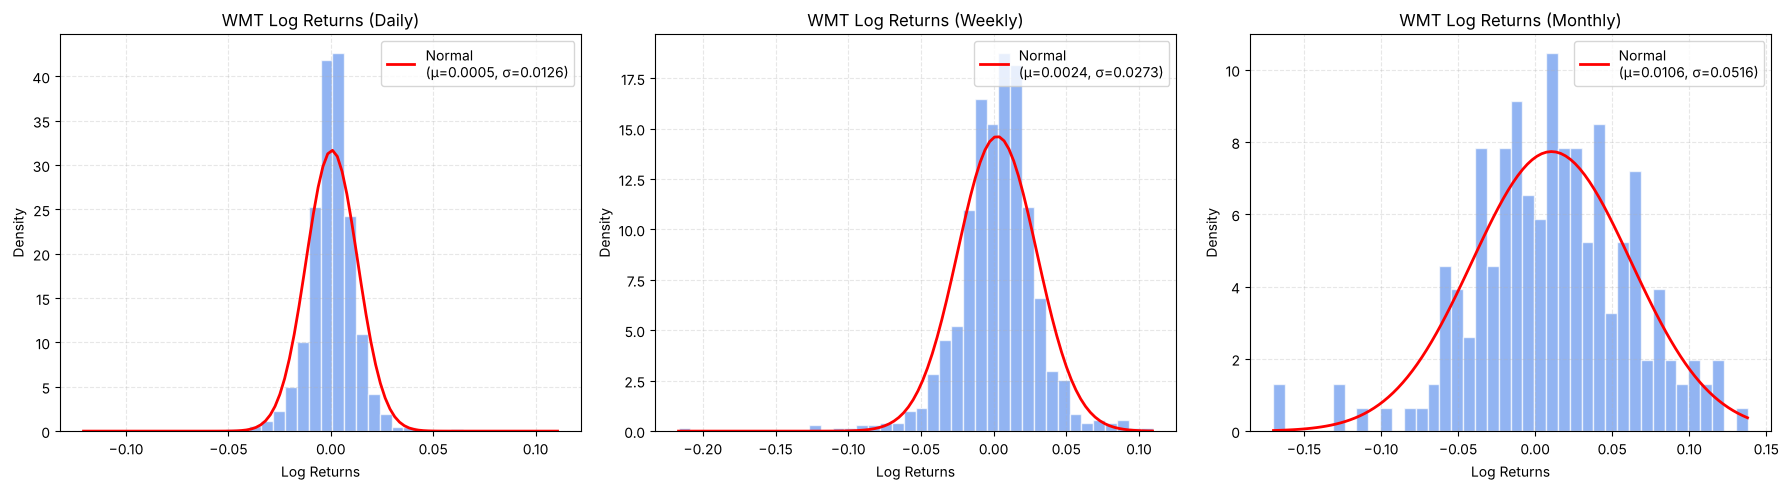

In [7]:
# Set up the figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

frequencies = [('Daily', daily_returns, axes[0]),
               ('Weekly', weekly_returns, axes[1]),
               ('Monthly', monthly_returns, axes[2])]

for title, data, ax in frequencies:
    # Histogram
    ax.hist(data, bins=40, density=True, color='cornflowerblue', edgecolor='white', alpha=0.7)

    # Fit the normal distribution (add.normal)
    mu, std = norm.fit(data)
    x = np.linspace(data.min(), data.max(), 100)
    p = norm.pdf(x, mu, std)

    # Draw the normal curve
    ax.plot(x, p, 'r-', linewidth=2, label=f'Normal\n(μ={mu:.4f}, σ={std:.4f})')

    # Visual details
    ax.set_title(f'WMT Log Returns ({title})')
    ax.set_xlabel('Log Returns')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/wmt_log_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

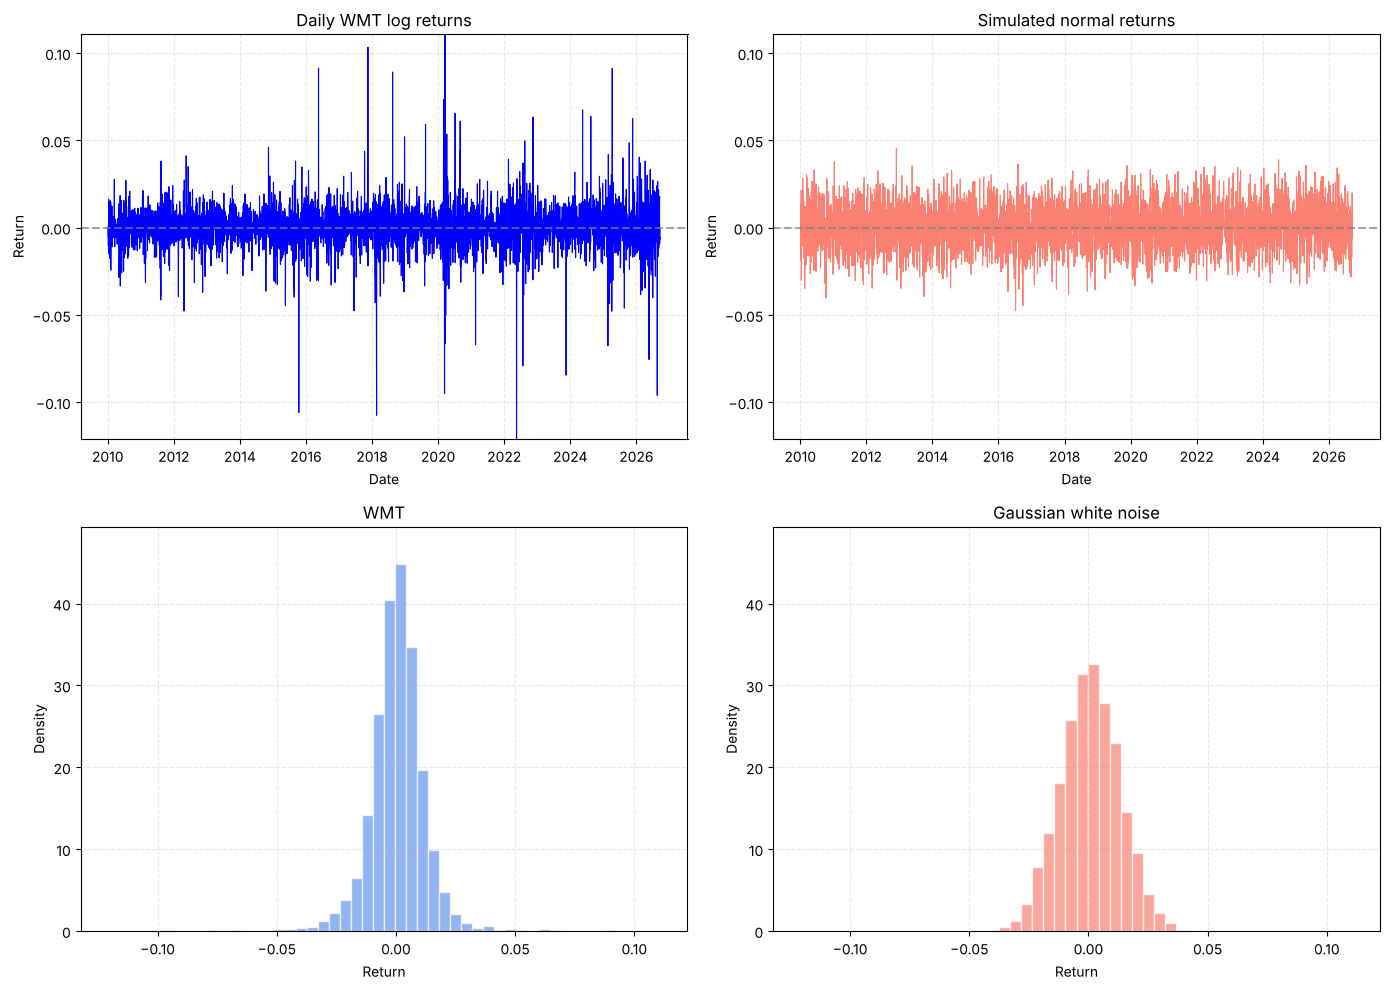

In [8]:
#(equivalent to set.seed(123) in R)
np.random.seed(123)

# Reuse the daily returns we already have
wmt_ret = daily_returns
# Generate Gaussian white noise with the same mean, standard deviation and length as WMT
mu = wmt_ret.mean()
std = wmt_ret.std()
gwn_daily = pd.Series(np.random.normal(loc=mu, scale=std, size=len(wmt_ret)), index=wmt_ret.index)

# Set common axis limits (so that the two series can be compared directly)
y_limits = (min(wmt_ret.min(), gwn_daily.min()), max(wmt_ret.max(), gwn_daily.max()))

# -------------------------------------------------------------------
# Create the 2x2 grid of charts (mfrow = c(2, 2) in R)
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Chart 1: actual time series (WMT) ---
axes[0, 0].plot(wmt_ret.index, wmt_ret, color='blue', linewidth=0.8)
axes[0, 0].axhline(0, color='grey', linestyle='--', alpha=0.7)
axes[0, 0].set_ylim(y_limits)
axes[0, 0].set_title('Daily WMT log returns')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Return')
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# --- Chart 2: simulated time series (Gaussian White Noise) ---
axes[0, 1].plot(gwn_daily.index, gwn_daily, color='salmon', linewidth=0.8)
axes[0, 1].axhline(0, color='grey', linestyle='--', alpha=0.7)
axes[0, 1].set_ylim(y_limits)
axes[0, 1].set_title('Simulated normal returns')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Return')
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# --- Create the same bins for both histograms ---
bins = np.linspace(y_limits[0], y_limits[1], 51)

# --- Chart 3: actual histogram (WMT) ---
count_wmt, _, _ = axes[1, 0].hist(wmt_ret, bins=bins, density=True, color='cornflowerblue', edgecolor='white', alpha=0.7)
axes[1, 0].set_title('WMT')
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# --- Chart 4: simulated histogram (Gaussian White Noise) ---
count_gwn, _, _ = axes[1, 1].hist(gwn_daily, bins=bins, density=True, color='salmon', edgecolor='white', alpha=0.7)
axes[1, 1].set_title('Gaussian white noise')
axes[1, 1].set_xlabel('Return')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

# Use the same Y-axis scale in both histograms for a visual comparison
max_y_hist = max(count_wmt.max(), count_gwn.max()) * 1.1
axes[1, 0].set_ylim(0, max_y_hist)
axes[1, 1].set_ylim(0, max_y_hist)

plt.tight_layout()
plt.savefig('../figures/wmt_log_returns_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()

## Fitted normal density on the actual histogram

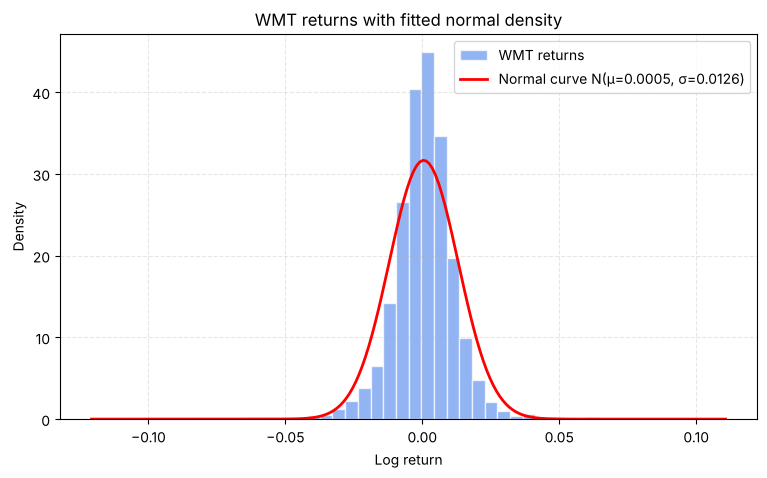

In [9]:
#Create the histogram
plt.figure(figsize=(9, 5))

count, bins, _ = plt.hist(
    wmt_ret,
    bins=50,
    density=True,
    color='cornflowerblue',
    edgecolor='white',
    alpha=0.7,
    label='WMT returns'
)

# Overlay the curve of the fitted normal distribution
mu = wmt_ret.mean()
std = wmt_ret.std()

x = np.linspace(wmt_ret.min(), wmt_ret.max(), 200)
p = norm.pdf(x, mu, std)  # dnorm in R is the pdf (probability density function) in scipy

plt.plot(x, p, color='red', linewidth=2, label=f'Normal curve N(μ={mu:.4f}, σ={std:.4f})')

# Visual settings equivalent to R
plt.title("WMT returns with fitted normal density")
plt.xlabel("Log return")
plt.ylabel("Density")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig('../figures/wmt_distribution_with_normal.png', dpi=150, bbox_inches='tight')
plt.show()

## Empirical cumulative distribution function

Empirical probability of a daily drop greater than 5%:


,Threshold,Empirical_probability
0,-0.051293,0.002856


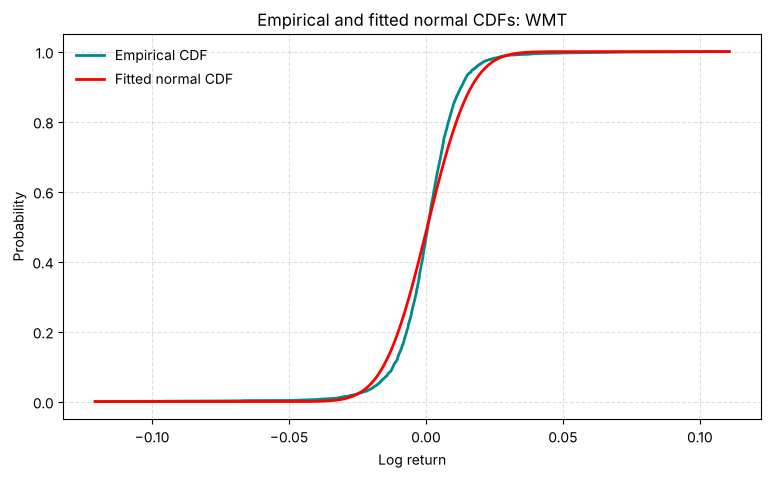

In [10]:
# the threshold (5% drop -> log(0.95)) and compute the empirical probability
threshold = np.log(0.95)
f_hat = (wmt_ret <= threshold).mean()

# Create and display the table (equivalent to knitr::kable)
prob_table = pd.DataFrame({
    'Threshold': [threshold],
    'Empirical_probability': [f_hat]
})

print("Empirical probability of a daily drop greater than 5%:")
display(prob_table.round(6))

# Compute the ECDF (empirical cumulative distribution function)
# We give ECDF a copy (.copy()) because ECDF sorts the data it receives. wmt_ret is just
# another name for daily_returns, so with some library versions (pandas 2.2 + numpy 2)
# daily_returns itself would end up sorted and the ACF results further down would be wrong.
ecdf = ECDF(wmt_ret.copy())

# Draw the CDF chart (empirical vs theoretical normal)
plt.figure(figsize=(9, 5))

# Actual ECDF of the data (green line)
x_ecdf = np.sort(wmt_ret)
plt.plot(x_ecdf, ecdf(x_ecdf), color='darkcyan', linewidth=2, label='Empirical CDF')

# Theoretical normal CDF (red line)
mu, std = wmt_ret.mean(), wmt_ret.std()
x = np.linspace(wmt_ret.min(), wmt_ret.max(), 300)
plt.plot(x, norm.cdf(x, mu, std), color='red', linewidth=2, label='Fitted normal CDF')


plt.title("Empirical and fitted normal CDFs: WMT")
plt.xlabel("Log return")
plt.ylabel("Probability")
plt.legend(loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Empirical quantiles and percentiles

In [11]:
import pandas as pd

# 1. Define the vector of probabilities
probs = [0.01, 0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975, 0.99]

# 2. Compute the WMT quantiles using interpolation='linear' (equivalent to type=7 in R)
ret_quant_wmt = daily_returns.quantile(probs, interpolation='linear')

# 3. Format as a DataFrame with a column name
quantile_table = pd.DataFrame(ret_quant_wmt)
quantile_table.columns = ['WMT']
quantile_table.index.name = 'quantile'

# Display with 5 decimal places (knitr::kable style)
print("Daily log-return quantiles")
display(quantile_table.round(5))

import pandas as pd

# Use our Walmart daily returns variable
wmt_summary = daily_returns.describe()

# Arrange with the same names/order as R's summary()
summary_r = pd.Series({
    'Min.': wmt_summary['min'],
    '1st Qu.': wmt_summary['25%'],
    'Median': wmt_summary['50%'],
    'Mean': wmt_summary['mean'],
    '3rd Qu.': wmt_summary['75%'],
    'Max.': wmt_summary['max']
}, name='WMT')

# Display formatted as a table
display(pd.DataFrame(summary_r).round(6))

Daily log-return quantiles


,WMT
quantile,
0.010,-0.03254
0.025,-0.02376
0.050,-0.01746
0.250,-0.00535
0.500,0.00069
0.750,0.00655
0.950,0.01741
0.975,0.02240
0.990,0.03170


,WMT
Min.,-0.120765
1st Qu.,-0.005347
Median,0.000686
Mean,0.000503
3rd Qu.,0.006549
Max.,0.110723


In [12]:
import pandas as pd
import numpy as np

# 1. Define the initial value of the position (initial investment)
V0 = 100000  # Example: 100,000 € / $

# 2. Define the confidence levels and the corresponding left-tail probabilities
confidence_levels = ['99% confidence', '97.5% confidence', '95% confidence']
probs = [0.01, 0.025, 0.05]

# -------------------------------------------------------------------
# Method 1: VaR transformed from the log returns
# -------------------------------------------------------------------
# Reuses 'daily_returns' (which is already the WMT series)
q_log = daily_returns.quantile(probs, interpolation='linear')
var_log_transformed = -V0 * (np.exp(q_log) - 1)

df_var_log = pd.DataFrame({'WMT': var_log_transformed.values}, index=confidence_levels)

print("One-day VaR: transformed log quantiles")
display(df_var_log.round(1))

# -------------------------------------------------------------------
# Method 2: VaR directly from the simple returns
# -------------------------------------------------------------------
# Get the simple returns (pct_change) from the WMT price history
wmt_prices = wmt['Adj Close'] if 'Adj Close' in wmt.columns else wmt['Close']
simple_returns = wmt_prices.pct_change().dropna()

q_simple = simple_returns.quantile(probs, interpolation='linear')
var_direct = -V0 * q_simple

df_var_direct = pd.DataFrame({'WMT': var_direct.values}, index=confidence_levels)

print("One-day VaR: direct simple-return quantiles")
display(df_var_direct.round(1))

One-day VaR: transformed log quantiles


,WMT
99% confidence,3201.6
97.5% confidence,2347.6
95% confidence,1730.5


One-day VaR: direct simple-return quantiles


,WMT
99% confidence,3201.6
97.5% confidence,2347.6
95% confidence,1730.5


## Quantile-quantile plots with Standardisation

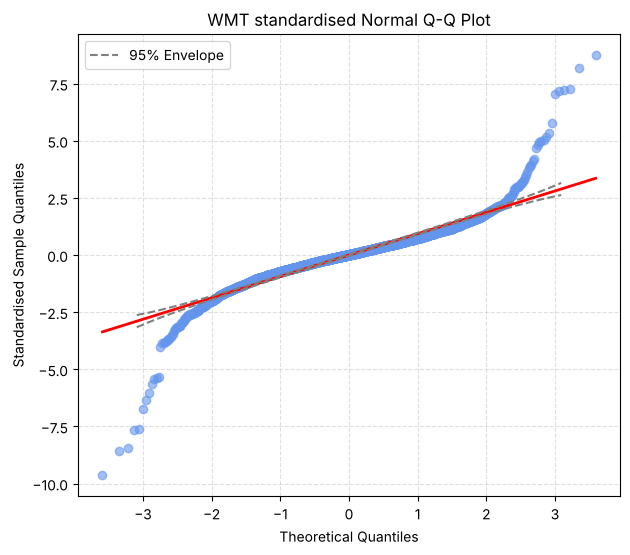

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Get the Walmart returns
wmt_ret = daily_returns.dropna()

# 2. Standardise the series (Z-score: mean 0, standard deviation 1)
wmt_std = (wmt_ret - wmt_ret.mean()) / wmt_ret.std()

# 3. Create the figure for the standardised QQ-plot
fig, ax = plt.subplots(figsize=(7, 6))

# QQ-plot with the standardised data
(osm, osr), (slope, intercept, r) = stats.probplot(wmt_std, dist="norm", plot=ax)

# Visual customisation
ax.get_lines()[0].set_color('cornflowerblue')
ax.get_lines()[0].set_alpha(0.6)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2)

# 95% confidence envelope
n = len(wmt_std)
grid = np.linspace(0.001, 0.999, n)
theoretical_quantiles = stats.norm.ppf(grid)
se = (slope / stats.norm.pdf(theoretical_quantiles)) * np.sqrt(grid * (1 - grid) / n)

upper_env = (theoretical_quantiles * slope + intercept) + 1.96 * se
lower_env = (theoretical_quantiles * slope + intercept) - 1.96 * se

ax.plot(theoretical_quantiles, upper_env, color='gray', linestyle='--', label='95% Envelope')
ax.plot(theoretical_quantiles, lower_env, color='gray', linestyle='--')

# Title and axes
ax.set_title("WMT standardised Normal Q-Q Plot", fontsize=12)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Standardised Sample Quantiles")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper left')

plt.show()

## Student-t reference: an alternative tail shape

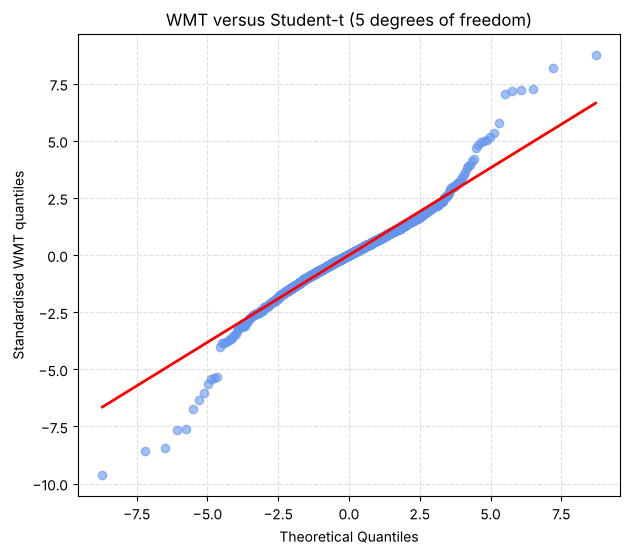

In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Use the Walmart daily returns and standardise them
wmt_ret = daily_returns.dropna()
wmt_std = (wmt_ret - wmt_ret.mean()) / wmt_ret.std()

# 2. Set the degrees of freedom (df = 5)
df_student = 5

# 3. Create the QQ-plot against the Student-t distribution
fig, ax = plt.subplots(figsize=(7, 6))

# stats.probplot using the 't' distribution with sparams=(df_student,)
(osm, osr), (slope, intercept, r) = stats.probplot(
    wmt_std,
    dist="t",
    sparams=(df_student,),
    plot=ax
)

# 4. Visual customisation (car::qqPlot style)
ax.get_lines()[0].set_color('cornflowerblue')  # Actual points
ax.get_lines()[0].set_markerfacecolor('cornflowerblue')
ax.get_lines()[0].set_alpha(0.6)

ax.get_lines()[1].set_color('red')             # Theoretical line
ax.get_lines()[1].set_linewidth(2)

# Titles and axes
ax.set_title(f"WMT versus Student-t ({df_student} degrees of freedom)", fontsize=12)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Standardised WMT quantiles")
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Shape characteristics and boxplots

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# 1. Use our Walmart daily returns variable
wmt_ret = daily_returns.dropna()

# 2. Compute the statistical moments
mean_val = wmt_ret.mean()
sd_val = wmt_ret.std()  # Sample standard deviation (ddof=1 by default in pandas)
skew_val = skew(wmt_ret)  # Skewness
kurt_val = kurtosis(wmt_ret, fisher=False)  # Raw kurtosis (Pearson)
ex_kurt_val = kurtosis(wmt_ret, fisher=True)  # Excess kurtosis (Kurtosis - 3)

# 3. Arrange in a table with 5 decimal places (knitr::kable style)
moments_wmt = pd.DataFrame({
    'Mean': [mean_val],
    'SD': [sd_val],
    'Skewness': [skew_val],
    'Kurtosis': [kurt_val],
    'Excess.Kurtosis': [ex_kurt_val]
}, index=['WMT']).T

print("Distributional moments of daily log returns")
display(moments_wmt.round(5))

Distributional moments of daily log returns


,WMT
Mean,0.00050
SD,0.01259
Skewness,-0.25459
Kurtosis,17.32108
Excess.Kurtosis,14.32108


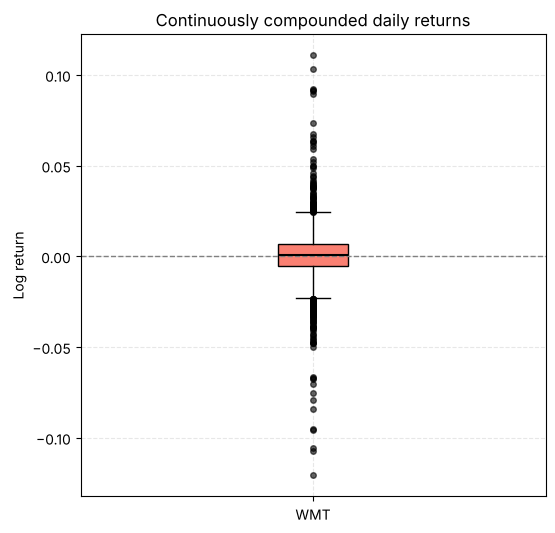

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Use the Walmart daily returns
wmt_ret = daily_returns.dropna()

# 2. Create the boxplot figure
plt.figure(figsize=(6, 6))

# Boxplot filled with 'brown1' / 'salmon'
box = plt.boxplot(
    wmt_ret,
    patch_artist=True,
    tick_labels=['WMT'],  # this argument was called 'labels' before matplotlib 3.9
    boxprops=dict(facecolor='salmon', color='black'),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=4, alpha=0.6)
)

# 3. Add a horizontal line at 0 (abline(h = 0, col = "grey50", lty = 2))
plt.axhline(y=0, color='grey', linestyle='--', linewidth=1)

# Visual settings equivalent to R
plt.title("Continuously compounded daily returns")
plt.ylabel("Log return")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

## Autocovariance and autocorrelation

In [17]:
import pandas as pd
from statsmodels.tsa.stattools import acf, acovf

# 1. Use the Walmart daily returns
wmt_ret = daily_returns.dropna()

# 2. Set the maximum number of lags (lag.max = 50 in R)
lag_max = 50

# 3. Autocorrelation (equivalent to acf(..., plot = FALSE))
acf_values = acf(wmt_ret, nlags=lag_max, fft=True)

# 4. Autocovariance (equivalent to acf(..., type = "covariance", plot = FALSE))
acov_values = acovf(wmt_ret, nlag=lag_max, fft=True)

# 5. Arrange the results in a DataFrame
df_acf_wmt = pd.DataFrame({
    'Lag': range(lag_max + 1),
    'Autocovariance': acov_values,
    'Autocorrelation': acf_values
}).set_index('Lag')

# Display the table with the first 10 lags
print("WMT Autocovariance and Autocorrelation (lag.max = 50):")
display(df_acf_wmt.head(10).round(6))

WMT Autocovariance and Autocorrelation (lag.max = 50):


,Autocovariance,Autocorrelation
Lag,,
0,0.000159,1.000000
1,-0.000005,-0.034392
2,-0.000001,-0.006115
3,-0.000001,-0.008737
4,-0.000007,-0.041313
5,-0.000002,-0.010617
6,-0.000001,-0.008971
7,0.000003,0.019368
8,-0.000007,-0.043893


## ACF of returns: dependence in the level of returns

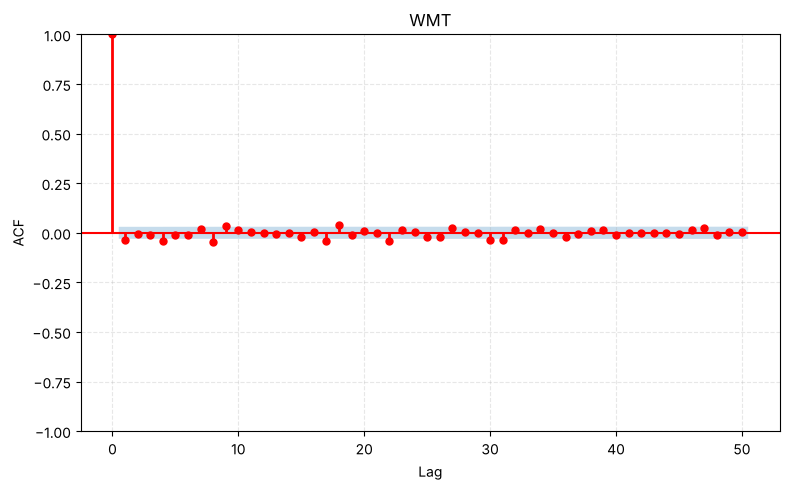

In [18]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Use the Walmart daily returns
wmt_ret = daily_returns.dropna()

# 2. Create the figure for the ACF chart
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Draw the ACF (lag.max = 50, red colour as in R)
plot_acf(
    wmt_ret,
    lags=50,
    ax=ax,
    alpha=0.05,            # 95% confidence interval (shaded area/lines)
    color='red',
    vlines_kwargs={'colors': 'red', 'linewidth': 2},
    title="WMT"
)

# Additional visual settings (R style)
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## ACF of squared returns: dependence in return magnitude

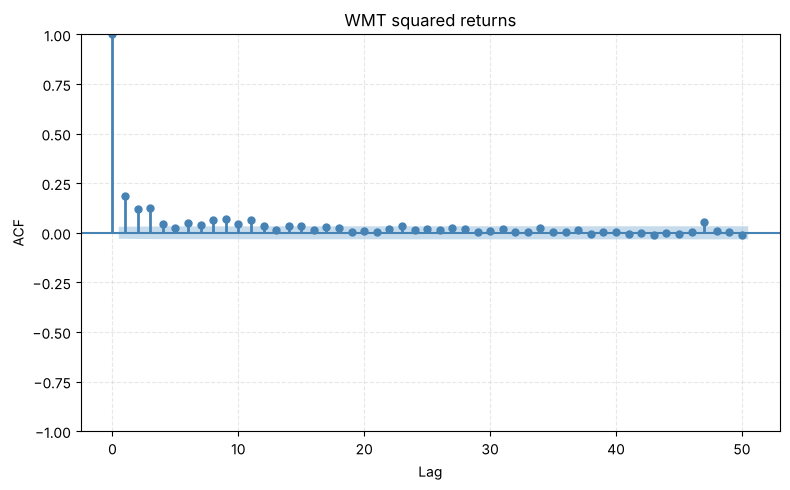

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Get the Walmart daily returns
wmt_ret = daily_returns.dropna()

# 2. Compute the squared log returns (a proxy for volatility)
wmt_ret_sq = wmt_ret ** 2

# 3. Create the figure for the ACF chart
fig, ax = plt.subplots(figsize=(8, 5))

# 4. Draw the ACF of the squared returns (lag.max = 50, steelblue colour as in R)
plot_acf(
    wmt_ret_sq,
    lags=50,
    ax=ax,
    alpha=0.05,            # 95% confidence interval
    color='steelblue',
    vlines_kwargs={'colors': 'steelblue', 'linewidth': 2},
    title="WMT squared returns"
)

# Visual settings equivalent to R
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## WMT vs the market: SPY (investable) and ^GSPC (index)

- **SPY** is an ETF that can be bought; its adjusted price includes dividends, just like WMT's → it is the correct comparison.
- **^GSPC** is the S&P 500 index: it is **not investable** and it is a price index **without dividends**, so it understates the total market return
  (by about 1.5–2 percentage points per year).
- We first select the columns and only then drop the NaN (if we apply `dropna()` to the whole table, the TSLA NaN cut off the first 6 months).

In [20]:
import pandas as pd
import numpy as np

# 1. Load the dataset of daily (log) returns
df_ret = pd.read_csv('data/daily_log_returns.csv', index_col=0, parse_dates=True)

# 2. Select WMT, SPY (investable ETF, with dividends) and ^GSPC (index, without dividends)
#    We first choose the columns and only then drop the NaN
df_sub = df_ret[['WMT', 'SPY', '^GSPC']].dropna()
df_sub.columns = ['WMT', 'SPY (ETF, with dividends)', '^GSPC (index, no dividends)']

# 3. Set the annualisation scale (252 trading days)
annual_scale = 252

# 4. Compute the daily and annualised statistics
mu_log = df_sub.mean()
Sigma_log = df_sub.cov()
sd_log = np.sqrt(np.diag(Sigma_log))

mu_annual = mu_log * annual_scale
Sigma_annual = Sigma_log * annual_scale
sd_annual = sd_log * np.sqrt(annual_scale)

# 5. Table 1: Summary of the estimates
annual_summary = pd.DataFrame({
    'Daily_log_mean': mu_log,
    'Daily_log_SD': sd_log,
    'Annual_log_mean': mu_annual,
    'Annual_log_SD': sd_annual,
    'Annual_geometric_growth': np.expm1(mu_annual)
})

print("Daily and annualised log-return estimates (WMT vs SPY and ^GSPC):")
display(annual_summary.round(5))

# 6. Table 2: Daily covariance matrix
print("\nDaily log-return covariance matrix:")
display(Sigma_log.round(7))

# 7. Table 3: Annualised covariance matrix
print("\nAnnualised log-return covariance matrix:")
display(Sigma_annual.round(5))

Daily and annualised log-return estimates (WMT vs SPY and ^GSPC):


,Daily_log_mean,Daily_log_SD,Annual_log_mean,Annual_log_SD,Annual_geometric_growth
WMT,0.00050,0.01259,0.12682,0.19993,0.13522
"SPY (ETF, with dividends)",0.00052,0.01077,0.13196,0.17092,0.14106
"^GSPC (index, no dividends)",0.00045,0.01084,0.11454,0.17214,0.12136



Daily log-return covariance matrix:


,WMT,"SPY (ETF, with dividends)","^GSPC (index, no dividends)"
WMT,0.000159,0.000057,0.000057
"SPY (ETF, with dividends)",0.000057,0.000116,0.000117
"^GSPC (index, no dividends)",0.000057,0.000117,0.000118



Annualised log-return covariance matrix:


,WMT,"SPY (ETF, with dividends)","^GSPC (index, no dividends)"
WMT,0.03997,0.01427,0.01440
"SPY (ETF, with dividends)",0.01427,0.02921,0.02938
"^GSPC (index, no dividends)",0.01440,0.02938,0.02963
